# Data Evaluation: User Study

## 0. Setup

In [49]:
import pandas as pd
import matplotlib as mpl

data_df = pd.read_csv('../eval-toolchain/eval-data.csv')
data_df

,participant,p_id,date,group,s_issues_miro,s_issues_pixie,s_issues_correct_miro,s_issues_correct_pixie,p_answered_miro,p_answered_pixie,p_answered_correct_miro,p_answered_correct_pixie
0,2,PA40344,2026-06-29,AP,5,3,NaN,NaN,6,6,NaN,NaN
1,5,MA7125,2026-06-30,AM,2,3,NaN,NaN,2,3,NaN,NaN
2,6,PA45003,2026-06-30,AP,2,1,NaN,NaN,3,4,NaN,NaN
3,4,PB54700,2026-06-30,BP,3,2,NaN,NaN,2,1,NaN,NaN
4,7,MB24145,2026-06-30,BM,3,2,NaN,NaN,1,4,NaN,NaN
5,11,MB50964,NaN,BM,2,4,NaN,NaN,1,2,NaN,NaN
6,10,PA81918,NaN,AP,6,3,NaN,NaN,2,4,NaN,NaN
7,1,MA12534,2026-06-29,AM,3,0,NaN,NaN,2,3,NaN,NaN
8,9,MA95935,2026-06-30,AM,2,0,NaN,NaN,2,2,NaN,NaN
9,8,PB34703,2026-06-30,BP,2,4,NaN,NaN,6,4,NaN,NaN


## 1. Data Exploration

### Total Numbers of Issues/Answered Questions

includes incorrect answers

In [51]:
total_counts_data_cols = [
    's_issues_miro',
    's_issues_pixie',
    'p_answered_miro',
    'p_answered_pixie',
]
total_counts_solvability = [
    's_issues_miro',
    's_issues_pixie',

]
total_counts_pacing = [
    'p_answered_miro',
    'p_answered_pixie',
]
#num_data_df = data_df[num_data_cols]
#num_data_df.index = data_df['p_id']
#plot = num_data_df.plot.pie(subplots=True, figsize=(5, 5))

#### Distribution of Total Number of Answered Questions Across Participants By Tool

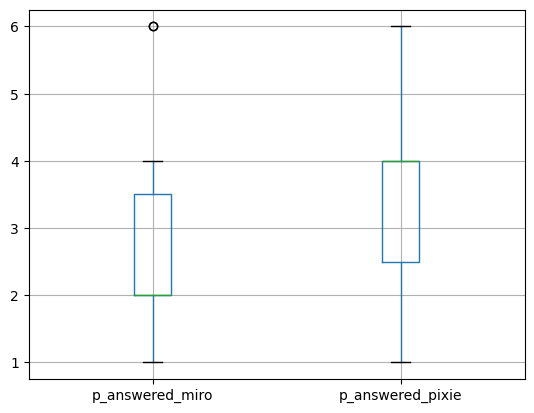

In [53]:
total_pacing_boxplot = data_df.boxplot(column=total_counts_pacing)

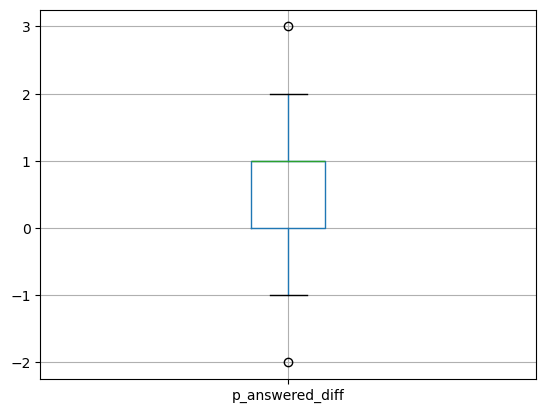

In [61]:
data_df['p_answered_diff'] = data_df['p_answered_pixie'] - data_df['p_answered_miro']
pacing_diff = data_df.boxplot(column=['p_answered_diff'])

### Timeseries

In [56]:
timeseries_data_df = pd.read_csv('../eval-toolchain/time_series/all.csv')
timeseries_data_df

,p_id,group,task,timestamp,tag,note,timedelta
0,PA40344,AP,solvability_pixie,01:27:30,STA,NaN,0
1,PA40344,AP,solvability_pixie,01:27:44,OBS,pathfinding start-room after boss,14
2,PA40344,AP,solvability_pixie,01:28:08,vb,ath blocked to boss,38
3,PA40344,AP,solvability_pixie,01:28:45,OBS,successive pathfinding,75
4,PA40344,AP,solvability_pixie,01:28:56,vb,oftlock 14,86
...,...,...,...,...,...,...,...
373,MB67500,BM,pacing_miro,15:39:55,sec,ion A faster on average,250
374,MB67500,BM,pacing_miro,15:40:25,inc,"eases: 16-18, 21-2 to 21-3",280
375,MB67500,BM,pacing_miro,15:40:45,rem,"rk: need boss key, but same result",300
376,MB67500,BM,pacing_miro,15:41:07,Q4A,miniboss ~~21-3~~ 15,322


#### Timeseries: Answers

In [63]:
answers_data_df = timeseries_data_df[timeseries_data_df['tag'].isin(['Q1A', 'Q2A', 'Q3A', 'Q4A', 'Q5A', 'Q6A'])]
answers_data_df

,p_id,group,task,timestamp,tag,note,timedelta
11,PA40344,AP,pacing_pixie,01:43:52,Q1A,q1 not steadily increasing,41
12,PA40344,AP,pacing_pixie,01:45:10,Q2A,b shorter than a,119
13,PA40344,AP,pacing_pixie,01:45:36,Q3A,more enemies in b than c,145
14,PA40344,AP,pacing_pixie,01:46:51,Q4A,miniboss 18 or 7,220
15,PA40344,AP,pacing_pixie,01:47:17,Q5A,9-3 to 5 sharpest increase,246
...,...,...,...,...,...,...,...
342,PB34703,BP,pacing_miro,15:47:04,Q6A,"9-1, 8",235
360,MB67500,BM,pacing_pixie,15:42:40,Q1A,number of enemies does not increase,40
364,MB67500,BM,pacing_pixie,15:45:24,Q4A,miniboss 11,204
371,MB67500,BM,pacing_miro,15:38:52,Q1A,"44 total, 15 rooms -> 4s",187


##### Distribution of Answer Events Across Time

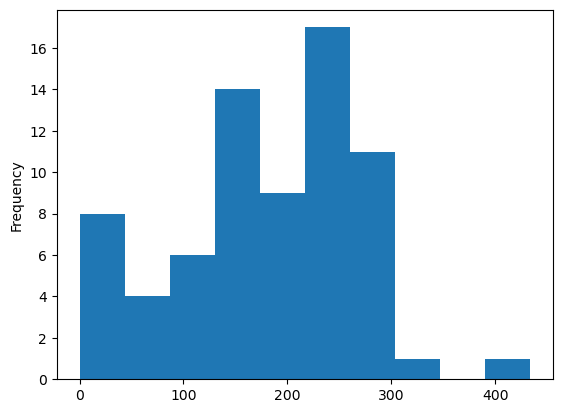

In [64]:
ax3 = answers_data_df['timedelta'].plot.hist()